#**Team1 IST 707 Project Checkpoint**


---

##Fourth Down Decision-Making & Coaching Tendencies in the NFL


---
#Team Members
**Point of Contact:** Fred Gullo
Team Members: Fred Gullo, Gavin Stein, Jared Weber


**Overview:**

*What are we trying to do?*

This project investigates fourth down decision-making in the NFL, with a focus on understanding how situational context, field position, and coaching tendencies interact to influence play calls and outcomes. A secondary thread examines the impact of the 2024 dynamic kickoff rule change on special teams behavior. The ultimate goal is to build predictive models capable of classifying fourth down decisions and evaluating their success, while attributing patterns to specific coaching staffs across seasons.

*What is new and why will it succeed?*

Traditionally, fourth down decision making is based on a few factors: the value of punting (the negative expected value of a possession from where the punt is downed, i.e. a possession for the other team), the expected value of kicking a field goal (3 * probability of making the field goal given the distance), the score of the game, and field position.
Our model is going to include additional factors, namely the playcallers and formations. We also plan to apply clustering methods and find groups of similar fourth down situations.

*Who cares?*

The NFL is the largest professional sports league in the world. Teams are always looking for opportunities to shift the odds in their favor, even if it is only by a few percent. The margins of victory are incredibly slim, and any opportunity to optimize decision making must be taken advantage of.

In [ ]:
import pandas as pd

# Load all datasets with low_memory=False to suppress warnings
fourth_downs_2021 = pd.read_csv('fourth_downs_2018_2019.csv', low_memory=False)
fourth_downs_2022 = pd.read_csv('fourth_downs_2020_2021.csv', low_memory=False)
fourth_downs_2023 = pd.read_csv('fourth_downs_2022_2023.csv', low_memory=False)
fourth_downs_2024 = pd.read_csv('fourth_downs_2024_2025.csv', low_memory=False)
play_callers = pd.read_excel('playcallers_by_week.xlsx', engine='openpyxl')
hard_count = pd.read_csv('hard_count_attempts.csv', low_memory=False)

# Step 1: Stack all fourth down datasets vertically
all_fourth_downs = pd.concat([
    fourth_downs_2021,
    fourth_downs_2022,
    fourth_downs_2023,
    fourth_downs_2024
], ignore_index=True)

print(f"Total fourth down plays: {len(all_fourth_downs)}")

# Step 2: Add flags to identify play types
all_fourth_downs['is_fourth_down'] = 1
all_fourth_downs['is_hard_count'] = 0

hard_count['is_fourth_down'] = 0
hard_count['is_hard_count'] = 1

# Step 3: Combine fourth downs and hard count plays
# Use play_id + game_id as the unique identifier
all_plays = pd.concat([all_fourth_downs, hard_count], ignore_index=True)

# Mark plays that appear in both datasets
play_key = all_plays['play_id'].astype(str) + '_' + all_plays['game_id'].astype(str)
duplicate_plays = play_key.duplicated(keep=False)

# For duplicates, keep one record but mark both flags as True
all_plays_dedup = all_plays.groupby(['play_id', 'game_id'], as_index=False).agg({
    'is_fourth_down': 'max',  # Will be 1 if any record has it
    'is_hard_count': 'max',   # Will be 1 if any record has it
    **{col: 'first' for col in all_plays.columns if col not in ['is_fourth_down', 'is_hard_count', 'play_id', 'game_id']}
})

print(f"Total unique plays (fourth downs + hard count): {len(all_plays_dedup)}")
print(f"Plays that are BOTH fourth down AND hard count: {(all_plays_dedup['is_fourth_down'] == 1) & (all_plays_dedup['is_hard_count'] == 1).sum()}")

# Step 4: Join with play callers - filter for offensive play callers
offensive_play_callers = play_callers[play_callers['side_of_ball'] == 'off'].copy()

# Join on team (posteam) and season
final_dataset = all_plays_dedup.merge(
    offensive_play_callers[['team', 'season', 'playcaller', 'weeks']],
    left_on=['posteam', 'season'],
    right_on=['team', 'season'],
    how='left'
)

# Clean up duplicate team column
final_dataset = final_dataset.drop(columns=['team'])

print(f"\nFinal dataset shape: {final_dataset.shape}")
print(f"Plays with play caller info: {final_dataset['playcaller'].notna().sum()}")
print(f"Plays missing play caller info: {final_dataset['playcaller'].isna().sum()}")

# Show summary
print("\n--- Summary Statistics ---")
print(f"Fourth down plays only: {(final_dataset['is_fourth_down'] == 1) & (final_dataset['is_hard_count'] == 0).sum()}")
print(f"Hard count plays only: {(final_dataset['is_fourth_down'] == 0) & (final_dataset['is_hard_count'] == 1).sum()}")
print(f"Both fourth down AND hard count: {((final_dataset['is_fourth_down'] == 1) & (final_dataset['is_hard_count'] == 1)).sum()}")

# Save the final dataset
final_dataset.to_csv('combined_fourth_downs_hardcount.csv', index=False)
print("\n✓ Saved to 'combined_fourth_downs_hardcount.csv'")


FileNotFoundError: [Errno 2] No such file or directory: 'fourth_downs_2018_2019.csv'

*Data*

Play-by-play data sourced from nflfastR and playcaller data manually created

**nflfastR:**
- The package contains NFL play-by-play data back to 1999
- Includes completion probability, completion percentage over expected, and expected yards after the catch in play-by-play going back to 2006
- Includes drive information, including drive starting position and drive result
- Includes series information, including series number and series success
- Hosts a release of play-by-play data going back to 1999 for very quick access
- Features models for Expected Points, Win Probability, Completion Probability, and Yards After the Catch


*Dimensionality Reduction*

Before applying clustering methods or a model, we had to reduce the dimensionality of this dataset. Originally, it included 372 variables, many of which recorded information that was redundant/repeated or unnecessary for the purposes of our analysis. We wrote a function to drop these columns so we can update our selection as the project progresses.

*One-Hot Encoding*

There are a lot of categorical variables in our dataset signifying play outcome, which team is on offense/defense, which team recovered/forced fumbles/kicks, and many more. These would need to be encoded into binary variables, but greatly increased the width of our dataset. This was not ideal for the amount of data we have, so we knew we had to come up with a solution.

One issue we encountered was the presence of numerous categorical variables the contained a team identifier (32 unique values). We decided to only keep two of them to identify the offensive and defensive teams, and then create binary variables to signify if the categorical variable referred to the offensive team, defensive team, or neither. This brought our column count down by more than 150. More dimensionality reduction is likely to be part of future weeks of this project, as we still have a whopping 320 features.

*Dimensionality Reduction & Feature Engineering*

Milestone 2 work has been substantially completed, with PCA finalized and the correlation heatmap deprioritized pending further variable selection.
Field Position Engineering (FG): Raw field position strings (e.g., "BUF 30") were converted into a universal numeric format where higher values consistently represent proximity to the opponent's end zone, regardless of which team is on offense. This was implemented as a reusable function applicable across all project CSVs.
Categorical Encoding (GS): An encoding pipeline was developed for the full dataset. Ordinal variables were one-hot encoded and others label encoded. Null values were replaced with zeros, and columns with an excessive proportion of missing values were dropped. The pipeline was written to be modular, allowing straightforward updates as variable selection continues to evolve.
Dimensionality Reduction (FG/JW/GS): The raw combined dataset contained 372 variables. A key insight during this phase was that several categorical columns (e.g., fumble_recovery_team) stored team-level information that, after encoding, would expand to 32 binary columns per variable. These were replaced with single binary features — for example, fumble_recovered_by_posteam — reducing the encoded column count from 515 to under 400 while preserving all meaningful information. A reproducible filtering pipeline was built with pattern-based exclusion and sparsity thresholds (≥99% zeros/nulls), and removed/kept variable lists were exported for documentation.
PCA (JW): Principal Component Analysis was applied to the encoded dataset after z-score normalization. Explained variance ratios were evaluated to determine the appropriate number of components, and component loadings were examined to assess variable contributions. The PCA-transformed feature set is ready for integration into clustering and modeling pipelines.
Correlation Heatmap (FG): Initial work began on a correlation heatmap, but given the breadth of the feature space at the time, the visualization was not interpretable enough to be actionable. This will be revisited once the variable set is finalized for modeling.


In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

def create_is_posteam_column(df, team_col):
    new_col_name = team_col.replace('_team', '_is_posteam')
    df[new_col_name] = (df[team_col] == df['posteam']).astype(int)
    ## Drop old team column
    df = df.drop(columns=[team_col])
    return df

def encode_categoricals(df):
    df_encoded = df.copy()

    # Columns to drop
    drop_cols = [
        'play_id',
        'game_id',
        'old_game_id',
        'side_of_field',
        'quarter_end',
        'qb_kneel',
        'qb_spike',
        'qb_scramble',
        'extra_point_result',
        'two_point_conv_result',
        'timeout',
        'timeout_team',
        'td_player_name',
        'td_player_id',
        'no_score_prob',
        'opp_fg_prob',
        'opp_safety_prob',
        'opp_td_prob',
        'fg_prob',
        'safety_prob',
        'td_prob',
        'extra_point_prob',
        'two_point_conversion_prob',
        'epa',
        'total_home_epa',
        'total_away_epa',
        'total_home_rush_epa',
        'total_away_rush_epa',
        'total_home_pass_epa',
        'total_away_pass_epa',
        'air_epa',
        'yac_epa',
        'comp_air_epa',
        'comp_yac_epa',
        'total_home_comp_air_epa',
        'total_away_comp_air_epa',
        'total_home_comp_yac_epa',
        'total_away_comp_yac_epa',
        'total_home_raw_air_epa',
        'total_away_raw_air_epa',
        'total_home_raw_yac_epa',
        'total_away_raw_yac_epa',
        'wp',
        'def_wp',
        'home_wp',
        'away_wp',
        'wpa',
        'vegas_wpa',
        'vegas_home_wpa',
        'home_wp_post',
        'away_wp_post',
        'vegas_wp',
        'vegas_home_wp',
        'total_home_rush_wpa',
        'total_away_rush_wpa',
        'total_home_pass_wpa',
        'total_away_pass_wpa',
        'air_wpa',
        'yac_wpa',
        'comp_air_wpa',
        'comp_yac_wpa',
        'total_home_comp_air_wpa',
        'total_away_comp_air_wpa',
        'total_home_comp_yac_wpa',
        'total_away_comp_yac_wpa',
        'total_home_raw_air_wpa',
        'total_away_raw_air_wpa',
        'total_home_raw_yac_wpa',
        'total_away_raw_yac_wpa',
        'punt_blocked',
        'first_down_rush',
        'first_down_pass',
        'first_down_penalty',
        'third_down_converted',
        'third_down_failed',
        'interception',
        'punt_inside_twenty',
        'punt_in_endzone',
        'kickoff_inside_twenty',
        'kickoff_in_endzone',
        'kickoff_out_of_bounds',
        'kickoff_downed',
        'kickoff_fair_catch',
        'fumble_forced',
        'fumble_out_of_bounds',
        'solo_tackle',
        'safety',
        'tackled_for_loss',
        'fumble_lost',
        'own_kickoff_recovery',
        'own_kickoff_recovery_td',
        'sack',
        'rush_touchdown',
        'return_touchdown',
        'extra_point_attempt',
        'two_point_attempt',
        'kickoff_attempt',
        'assist_tackle',
        'lateral_reception',
        'lateral_rush',
        'lateral_return',
        'lateral_recovery',
        'passer_player_id',
        'passer_player_name',
        'receiver_player_id',
        'receiver_player_name',
        'rusher_player_id',
        'rusher_player_name',
        'lateral_receiver_player_id',
        'lateral_receiver_player_name',
        'lateral_receiving_yards',
        'lateral_rusher_player_id',
        'lateral_rusher_player_name',
        'lateral_rushing_yards',
        'lateral_sack_player_id',
        'lateral_sack_player_name',
        'interception_player_id',
        'interception_player_name',
        'lateral_interception_player_id',
        'lateral_interception_player_name',
        'punt_returner_player_id',
        'punt_returner_player_name',
        'lateral_punt_returner_player_id',
        'lateral_punt_returner_player_name',
        'kickoff_returner_player_name',
        'kickoff_returner_player_id',
        'lateral_kickoff_returner_player_id',
        'lateral_kickoff_returner_player_name',
        'punter_player_id',
        'punter_player_name',
        'kicker_player_name',
        'kicker_player_id',
        'own_kickoff_recovery_player_id',
        'own_kickoff_recovery_player_name',
        'blocked_player_id',
        'blocked_player_name',
        'tackle_for_loss_1_player_id',
        'tackle_for_loss_1_player_name',
        'tackle_for_loss_2_player_id',
        'tackle_for_loss_2_player_name',
        'qb_hit_1_player_id',
        'qb_hit_1_player_name',
        'qb_hit_2_player_id',
        'qb_hit_2_player_name',
        'forced_fumble_player_1_team',
        'forced_fumble_player_1_player_id',
        'forced_fumble_player_1_player_name',
        'forced_fumble_player_2_team',
        'forced_fumble_player_2_player_id',
        'forced_fumble_player_2_player_name',
        'solo_tackle_1_team',
        'solo_tackle_2_team',
        'solo_tackle_1_player_id',
        'solo_tackle_2_player_id',
        'solo_tackle_1_player_name',
        'solo_tackle_2_player_name',
        'assist_tackle_1_player_id',
        'assist_tackle_1_player_name',
        'assist_tackle_1_team',
        'assist_tackle_2_player_id',
        'assist_tackle_2_player_name',
        'assist_tackle_2_team',
        'assist_tackle_3_player_id',
        'assist_tackle_3_player_name',
        'assist_tackle_3_team',
        'assist_tackle_4_player_id',
        'assist_tackle_4_player_name',
        'assist_tackle_4_team',
        'tackle_with_assist',
        'tackle_with_assist_1_player_id',
        'tackle_with_assist_1_player_name',
        'tackle_with_assist_1_team',
        'tackle_with_assist_2_player_id',
        'tackle_with_assist_2_player_name',
        'tackle_with_assist_2_team',
        'pass_defense_1_player_id',
        'pass_defense_1_player_name',
        'pass_defense_2_player_id',
        'pass_defense_2_player_name',
        'fumbled_1_player_id',
        'fumbled_1_player_name',
        'fumbled_2_player_id',
        'fumbled_2_player_name',
        'fumbled_2_team',
        'fumble_recovery_1_yards',
        'fumble_recovery_1_player_id',
        'fumble_recovery_1_player_name',
        'fumble_recovery_2_team',
        'fumble_recovery_2_yards',
        'fumble_recovery_2_player_id',
        'fumble_recovery_2_player_name',
        'sack_player_id',
        'sack_player_name',
        'half_sack_1_player_id',
        'half_sack_1_player_name',
        'half_sack_2_player_id',
        'half_sack_2_player_name',
        'penalty_player_id',
        'penalty_player_name',
        'replay_or_challenge',
        'replay_or_challenge_result',
        'defensive_two_point_attempt',
        'defensive_two_point_conv',
        'defensive_extra_point_attempt',
        'defensive_extra_point_conv',
        'safety_player_name',
        'safety_player_id',
        'nfl_api_id',
        'play_clock',
        'play_deleted',
        'st_play_type',
        'end_yard_line',
        'drive_first_downs',
        'drive_inside20',
        'drive_play_id_started',
        'drive_play_id_ended',
        'stadium_id',
        'aborted_play',
        'passer_jersey_number',
        'rusher_jersey_number',
        'receiver_jersey_number',
        'first_down',
        'passer_id',
        'rusher_id',
        'receiver_id',
        'jersey_number',
        'id',
        'fantasy_player_name',
        'fantasy_player_id',
        'fantasy_id',
        'home_opening_kickoff',
        'qb_epa',
        'xyac_epa',
        'home_timeouts_remaining',
        'away_timeouts_remaining',
        'kick_distance',
        'home_timeouts_remaining',
        'away_timeouts_remaining',
        'total_home_score',
        'total_away_score',
        'fourth_down_failed',
        'away_score',
        'home_score',
        'pass_attempt',
        'rush_attempt'
    ]

    # One-hot encode (nominal categories)
    onehot_cols = [
        'posteam', 'defteam',
        'season_type', 'posteam_type', 'game_half',
        'play_type', 'play_type_nfl',
        'pass_length', 'pass_location',
        'run_location', 'run_gap',
        'field_goal_result', 'series_result',
        'drive_start_transition', 'drive_end_transition', 'fixed_drive_result',
        'roof', 'surface', 'location', 'playcaller'
    ]

    team_cols = [
        'home_team',
        'away_team',
        'td_team',
        'penalty_team',
        'return_team',
        'fumbled_1_team',
        'fumble_recovery_1_team'
    ]

    # Label encode (ordinal)
    label_cols = [
        'week', 'qtr', 'down', 'drive', 'fixed_drive',
        'order_sequence', 'series',
    ]

    # Drop unwanted columns
    df_encoded = df_encoded.drop(columns=drop_cols, errors='ignore')

    # Apply team column function
    for col in team_cols:
        create_is_posteam_column(df_encoded, col)

    # One-hot encode
    onehot_cols_present = [col for col in onehot_cols if col in df_encoded.columns]
    if onehot_cols_present:
        df_encoded = pd.get_dummies(df_encoded, columns=onehot_cols_present, drop_first=True)

    # Label encode
    le = LabelEncoder()
    for col in label_cols:
        if col in df_encoded.columns:
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

    remaining_objects = df_encoded.select_dtypes(include=['object', 'str']).columns.tolist()
    df_encoded = df_encoded.drop(columns=remaining_objects, errors='ignore')

    return df_encoded


In [ ]:
df_encoded = encode_categoricals(final_dataset)
# Check shape before and after
print(f"Original shape: {final_dataset.shape}")
print(f"Encoded shape: {df_encoded.shape}")

*PCA Clustering*

To address the high dimensionality of our encoded dataset, we applied Principal Component Analysis (PCA) after standardizing all features using z-score normalization. PCA transforms the data into a set of orthogonal principal components that capture the maximum variance in the dataset while removing redundancy and multicollinearity. We evaluated the explained variance of each component using a scree plot to understand how information is distributed across components. To systematically reduce dimensionality while preserving the integrity of the data, we retained enough components to explain 95% of the total variance. This produces a more compact and efficient feature set that is better suited for clustering and downstream modeling, while maintaining nearly all of the original information.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Standardize features ---
scaler = StandardScaler()
df_encoded_scaled = scaler.fit_transform(df_encoded)

# --- Fit PCA ---
pca = PCA()
df_encoded_pca = pca.fit_transform(df_encoded_scaled)

# Convert to DataFrame (optional)
pca_df = pd.DataFrame(
    df_encoded_pca,
    columns=[f"PC{i+1}" for i in range(df_encoded_pca.shape[1])]
)

explained = pca.explained_variance_ratio_

plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

NameError: name 'df_encoded' is not defined

In [ ]:
## Evaluate Number of Components ##
pca = PCA(n_components=0.95)
df_encoded_reduced = pca.fit_transform(df_encoded_scaled)

print("Number of components retained:", pca.n_components_)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import subprocess
result = subprocess.run(['find', '/', '-name', 'encoded_fourth_downs.csv', '-not', '-path', '*/proc/*'],
                      capture_output=True, text=True)
print(result.stdout)

/encoded_fourth_downs.csv



#Basic model/visuals grouping fourth downs and modeling for their success

Milestones 3 & 4 — Clustering & Modeling

To evaluate fourth down performance beyond raw conversion rates, we built a basic logistic regression model to estimate each play’s expected probability of success based on situational variables such as distance to go, field position, score differential, quarter, time remaining, goal-to-go status, formation, and play type. We first reconstructed a single playcaller field from the encoded data, then limited the sample to true fourth down “go” decisions (rushes and passes) to focus specifically on conversion attempts. After fitting the model, we generated an expected conversion probability for each play and aggregated those results by playcaller to compare actual conversion rate against expected conversion rate. This allowed us to calculate a conversion over expected metric, which highlights which playcallers outperform or underperform the baseline expectation of their fourth down situations. We also applied a minimum sample threshold to improve stability and visualized the top playcallers by over-expected performance.




In [ ]:
#import data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss

# Load dataset
df = pd.read_csv("/encoded_fourth_downs.csv")

In [ ]:
# Get all playcaller columns
playcaller_cols = [c for c in df.columns if c.startswith("playcaller_")]

# Convert one-hot → single column
df["playcaller"] = df[playcaller_cols].idxmax(axis=1)

# Clean name
df["playcaller"] = df["playcaller"].str.replace("playcaller_", "", regex=False)

print(df["playcaller"].head())

0        Mike LaFleur
1         Dave Ragone
2         Matt Canada
3       Alex Van Pelt
4    Freddie Kitchens
Name: playcaller, dtype: object


In [ ]:
# Play type
fd = df[df["is_fourth_down"] == 1].copy()

fd_go = fd[(fd["pass_attempt"] == 1) | (fd["rush_attempt"] == 1)].copy()

playcaller_summary = (
    fd_go.groupby("playcaller")["fourth_down_converted"]
    .agg(["mean", "size"])
    .rename(columns={"mean": "success_rate", "size": "plays"})
    .reset_index()
)

# Filter out small samples (VERY IMPORTANT)
playcaller_summary = playcaller_summary[playcaller_summary["plays"] >= 50]

# Sort
playcaller_summary = playcaller_summary.sort_values("success_rate", ascending=False)

print(playcaller_summary.head(20))

              playcaller  success_rate  plays
1              Andy Reid      0.691057    123
85           Todd Monken      0.635294     85
46       Kliff Kingsbury      0.618785    181
21          Dirk Koetter      0.616667     60
14  Brian Schottenheimer      0.615385     78
77           Sean Payton      0.612245     98
25         Eric Bieniemy      0.597015     67
86          Zac Robinson      0.593220     59
37          Joe Lombardi      0.587302     63
19          Dave Canales      0.585106     94
36             Joe Brady      0.585034    147
78        Shane Steichen      0.574359    195
30            Greg Roman      0.571429    140
4            Ben Johnson      0.566138    189
41          Kellen Moore      0.562162    185
0          Alex Van Pelt      0.559796    393
40        Josh McDaniels      0.554622    119
53           Matt Canada      0.551724     58
42            Ken Dorsey      0.550000     80
11        Brian Callahan      0.541284    109


In [ ]:
features = [
    "ydstogo",
    "yardline_100",
    "score_differential",
    "qtr",
    "game_seconds_remaining",
    "goal_to_go",
    "shotgun",
    "pass_attempt",
    "rush_attempt",
]

X = fd_go[features]
y = fd_go["fourth_down_converted"]

model.fit(X, y)

# Predicted probability
fd_go["xConv"] = model.predict_proba(X)[:, 1]

In [ ]:
playcaller_oe = (
    fd_go.groupby("playcaller")
    .agg(
        actual=("fourth_down_converted", "mean"),
        expected=("xConv", "mean"),
        plays=("fourth_down_converted", "size")
    )
    .reset_index()
)

playcaller_oe["over_expected"] = playcaller_oe["actual"] - playcaller_oe["expected"]

# Filter for stability
playcaller_oe = playcaller_oe[playcaller_oe["plays"] >= 50]

# Sort
playcaller_oe = playcaller_oe.sort_values("over_expected", ascending=False)

print(playcaller_oe.head(20))

              playcaller    actual  expected  plays  over_expected
1              Andy Reid  0.691057  0.573738    123       0.117319
14  Brian Schottenheimer  0.615385  0.501716     78       0.113669
21          Dirk Koetter  0.616667  0.509493     60       0.107174
85           Todd Monken  0.635294  0.550203     85       0.085091
86          Zac Robinson  0.593220  0.526431     59       0.066789
37          Joe Lombardi  0.587302  0.522255     63       0.065047
46       Kliff Kingsbury  0.618785  0.554919    181       0.063865
19          Dave Canales  0.585106  0.527888     94       0.057219
25         Eric Bieniemy  0.597015  0.541458     67       0.055557
77           Sean Payton  0.612245  0.564275     98       0.047970
11        Brian Callahan  0.541284  0.503257    109       0.038027
18        Darrell Bevell  0.515625  0.482916     64       0.032709
40        Josh McDaniels  0.554622  0.523995    119       0.030626
36             Joe Brady  0.585034  0.554926    147       0.03

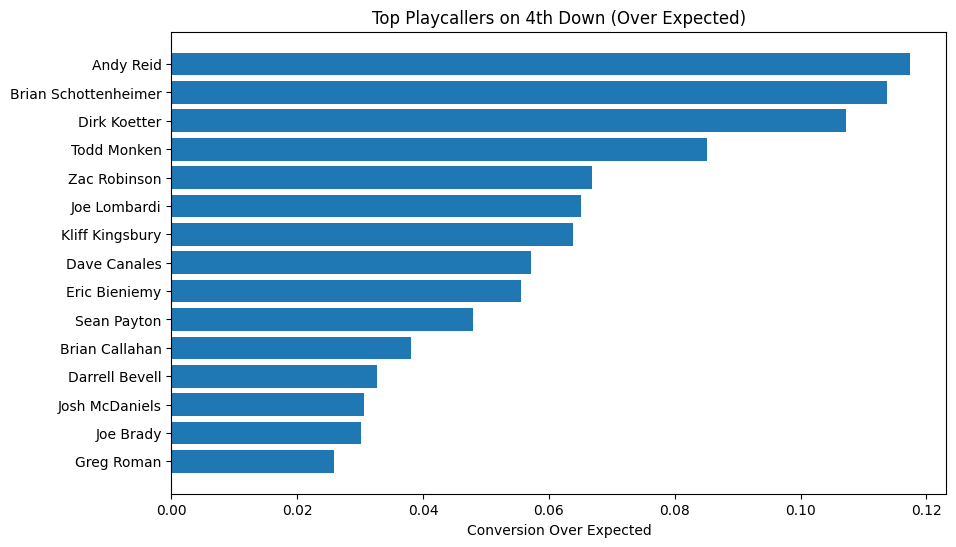

In [ ]:
plt.figure(figsize=(10, 6))

top = playcaller_oe.head(15)

plt.barh(top["playcaller"], top["over_expected"])
plt.xlabel("Conversion Over Expected")
plt.title("Top Playcallers on 4th Down (Over Expected)")
plt.gca().invert_yaxis()

plt.show()

*Future Work Plan*

*Cluster Analysis & Modeling*


For the next phase of the project, we plan to implement K-Means clustering on our 4th down situational vectors to group plays into distinct scenario types. To determine the optimal number of clusters, we will evaluate both the Elbow method and Silhouette scores, then project the results using t-SNE or PCA to make the clusters interpretable. From there, we will profile each cluster to assign meaningful labels that capture the situational context of each group, such as distinguishing desperate late-game situations from more aggressive mid-field decisions.
With clustering complete, we will shift toward building a baseline Logistic Regression model to predict 4th down decision outcomes, followed by hyperparameter tuning to improve performance.